# Logistic Regression with scikit-learn

<div style="background-color:#1e293b;padding:15px;border-left:6px solid #38bdf8;color:#e2e8f0">

In the previous notebook you implemented logistic regression from scratch to understand how the algorithm works. In practice you always use sklearn's <code>LogisticRegression</code>, which solves the same optimization problem with a much more efficient solver.

In this notebook you will run the full classification workflow on the <b>Telco Customer Churn</b> dataset: 7,000 telecom customers with features like tenure, monthly charges, and contract type. The target is whether a customer churned (left the service). You will train a model, inspect what it learned, get predictions and probabilities, and see how sklearn's regularization parameter shapes the result.

Evaluation metrics — precision, recall, and F1 — are the focus of the next tutorial.

</div>

---
## Step 1: Load and Explore the Data

The Telco Customer Churn dataset records whether each customer canceled their subscription.
Download `telco_churn.csv` from the course folder and place it in the same directory as this notebook.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

RANDOM_SEED = 23

df = pd.read_csv('telco_churn.csv')
print(f'shape: {df.shape}')
df.head()

shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
# Target distribution
print(f'Churn value counts:')
print(df['Churn'].value_counts())
print(f'\nPositive rate (churned): {(df["Churn"] == "Yes").mean():.3f}')
print(f'\nMissing values:')
print(df.isna().sum()[df.isna().sum() > 0])

Churn value counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Positive rate (churned): 0.266

Missing values:
Series([], dtype: int64)


> **Note:** About 26.5% of customers churned — a slight class imbalance. A model that always predicts "not churned" would be 73.5% accurate without learning anything. Keep this in mind when reading accuracy numbers.

---
## Step 2: Select Features and Split

We will start with four numerical features. `TotalCharges` is stored as text in this dataset, so we convert it with `pd.to_numeric(..., errors='coerce')`. The `coerce` setting means "turn anything you cannot parse into `NaN`" instead of raising an error, so a single call handles the whole column and leaves the unparseable values marked as missing.

In [ ]:
# TotalCharges is stored as text — convert it, marking anything unparseable as NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f'Unparseable TotalCharges values: {df["TotalCharges"].isna().sum()}')

df = df.dropna(subset=['TotalCharges'])
print(f'Rows remaining after dropping them: {len(df)}')

<class 'pandas.Series'>
Unparseable TotalCharges values: 0
Rows remaining after dropping them: 7032


> **Note:** Step 1 reported no missing values, yet the conversion just turned up 11 of them. Those cells were never empty — they hold a blank space `' '`, which `isna()` counts as a perfectly good value. Missing data does not always announce itself; converting a column to its proper type is often what exposes it.

**Stratified split:** Because only 26.5% of customers churned, a random split could hand train and test noticeably different churn rates. A stratified split prevents that by splitting each class separately and then combining the pieces: whatever train/test ratio you ask for is applied to the churners and to the non-churners individually, so both sets come out with the same churn rate as the full dataset. `stratify=y` switches this on, with `y` naming the values whose proportions should be preserved.

In [25]:
# Encode target: Yes → 1, No → 0
y = (df['Churn'] == 'Yes').astype(int).values

# Four numerical features — no encoding needed
feature_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
X = df[feature_cols].values

# Stratified 80/20 split — stratify=y preserves the churn rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print(f'Train: {X_train.shape}   Test: {X_test.shape}\n')
print(f'{"":<14}{"train":>8}{"test":>8}{"total":>8}')
print(f'{"churners":<14}{y_train.sum():>8}{y_test.sum():>8}{y.sum():>8}')
print(f'{"non-churners":<14}{(y_train == 0).sum():>8}{(y_test == 0).sum():>8}{(y == 0).sum():>8}')
print(f'\nChurn rate — train: {y_train.mean():.3f}   test: {y_test.mean():.3f}   full data: {y.mean():.3f}')

Train: (5625, 4)   Test: (1407, 4)

                 train    test   total
churners          1495     374    1869
non-churners      4130    1033    5163

Churn rate — train: 0.266   test: 0.266   full data: 0.266


> **Note:** The `test_size=0.2` above asks for a 20% test set, and stratification applied that ratio to each class separately: 1,495 of the 1,869 churners (80.0%) and 4,130 of the 5,163 non-churners (80.0%) went into the training set. That is why all three churn rates on the last line agree at 0.266. Without `stratify=y`, those two percentages would drift apart and the rates would no longer line up.
>
> How much this matters depends on the data: the smaller the dataset or the rarer the positive class, the more a random split can skew. With large, balanced data the difference is usually negligible.

So what does `stratify=y` actually buy us here? The cell below runs the same split *without* it, across ten seeds. Run it and compare each result against the stratified rate of 0.266.

One seed would not settle this — notice how much the answer depends on which seed you happen to look at.

In [26]:
# The same split WITHOUT stratify=y — how far does the churn rate drift from 0.266?
for seed in range(10):
    _, _, _, y_te = train_test_split(X, y, test_size=0.2, random_state=seed)
    print(f'seed {seed}:  test churn rate {y_te.mean():.4f}')

seed 0:  test churn rate 0.2623
seed 1:  test churn rate 0.2601
seed 2:  test churn rate 0.2658
seed 3:  test churn rate 0.2530
seed 4:  test churn rate 0.2665
seed 5:  test churn rate 0.2900
seed 6:  test churn rate 0.2630
seed 7:  test churn rate 0.2772
seed 8:  test churn rate 0.2509
seed 9:  test churn rate 0.2601


> **Note:** The drift here is mild. Across many seeds the unstratified test churn rate stays roughly between 0.24 and 0.29, and some seeds land right on 0.266 by luck. That is what the note above meant by negligible for large, fairly balanced data, and it is also why one seed cannot answer the question. Shrink the data and it stops being negligible: run this same experiment on a 300-row slice and the test churn rate swings between roughly 0.13 and 0.42. Stratification removes that variability entirely at no cost; the judgment call is about how much variability your data would have produced in the first place.

---
## Step 3: Scale Features

Logistic regression trains by iteratively minimizing the loss with a gradient-based solver, which makes it sensitive to feature scale. Our features live on wildly different scales: `SeniorCitizen` is 0 or 1, `tenure` runs 1–72 months, and `TotalCharges` reaches \$8,685. Without scaling, the feature with the largest numbers dominates the gradient, and the solver struggles to make progress on the rest.

> **Note:** You are calling sklearn here rather than writing a training loop, but there is still an iterative, gradient-driven optimizer underneath. sklearn's default solver, `lbfgs`, is a more sophisticated relative of the gradient descent you implemented by hand: it evaluates the gradient of the loss at every iteration and uses that history to take smarter steps. Linear regression can skip this and solve for its weights with a single formula, but logistic regression has no such formula, so an iterative search is unavoidable. Anything that walks the loss surface step by step is affected by features on wildly different scales.

Scaling buys a second thing that matters in this notebook: once every feature is in the same units (standard deviations), the learned coefficients become directly comparable to each other. That is what makes the coefficient plot in Step 5 readable.

Fit the scaler **on training data only**, then apply to both sets.

In [28]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit on train, transform train
X_test_sc  = scaler.transform(X_test)        # transform test using train statistics

print('Scaled feature means (should be ~0):', X_train_sc.mean(axis=0).round(3))
print('Scaled feature stds  (should be ~1):', X_train_sc.std(axis=0).round(3))

Scaled feature means (should be ~0): [-0.  0.  0. -0.]
Scaled feature stds  (should be ~1): [1. 1. 1. 1.]


---
## Step 4: Train the Model

The API is identical to `LinearRegression`: create, fit, predict. We keep sklearn's default settings for now and come back to the most important one in Step 6.

In [29]:
model = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
model.fit(X_train_sc, y_train)

# predict() returns class labels (0 or 1)
y_pred = model.predict(X_test_sc)

# predict_proba() returns probabilities for each class
# Column 0 = P(not churned), Column 1 = P(churned)
y_proba = model.predict_proba(X_test_sc)[:, 1]  # probability of churn

print(f'Test accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'\nFirst 5 predictions:  {y_pred[:5]}')
print(f'First 5 probabilities: {y_proba[:5].round(3)}')

Test accuracy: 0.7875

First 5 predictions:  [0 0 0 1 1]
First 5 probabilities: [0.201 0.48  0.037 0.592 0.514]


### Reading the Accuracy

**Accuracy** is the simplest classification metric: the share of test samples the model labeled correctly, which is just the number of correct predictions divided by the total number of predictions.

> **Note:** 78.8% sounds decent until you compare it with the baseline from Step 1: always predicting "not churned" scores 73.4% on this test set. Four numerical features bought us roughly five points over guessing the majority class. Accuracy also says nothing about *where* the errors fall — whether the model misses churners or falsely flags loyal customers. Splitting that apart is the job of the next tutorial.

### predict() vs predict_proba()

- `predict(X)` applies the 0.5 threshold and returns 0 or 1.
- `predict_proba(X)` returns the raw probability for each class. The second column is P(churn).

> **Note:** You need `predict_proba` for threshold analysis, covered in the next tutorial. Always call `model.fit()` before either method.

---
## Step 5: Interpret Coefficients

After fitting, `model.coef_` holds one weight per feature (in the same order as your feature columns).

A positive coefficient means: holding everything else constant, a one-standard-deviation increase in that feature raises the **log-odds** of churn. The log-odds are the model's internal score, the linear combination `z` computed before the sigmoid converts it to a probability. Pushing the log-odds up pushes the predicted probability up with it, so in plain terms a positive coefficient moves the customer toward churn, and a negative one moves them away.

In [35]:
print(f'Intercept: {model.intercept_[0]:.4f}')
print()
print(f'{'Feature':<18} {'Coefficient':>12}  Interpretation')
print('-' * 65)
for feat, coef in zip(feature_cols, model.coef_[0]):
    direction = 'more churn' if coef > 0 else 'less churn'
    print(f'{feat:<18} {coef:>12.4f}  higher value → {direction}')

Intercept: -1.5054

Feature             Coefficient  Interpretation
-----------------------------------------------------------------
SeniorCitizen            0.2383  higher value → more churn
tenure                  -1.7345  higher value → less churn
MonthlyCharges           0.8175  higher value → more churn
TotalCharges             0.4243  higher value → more churn


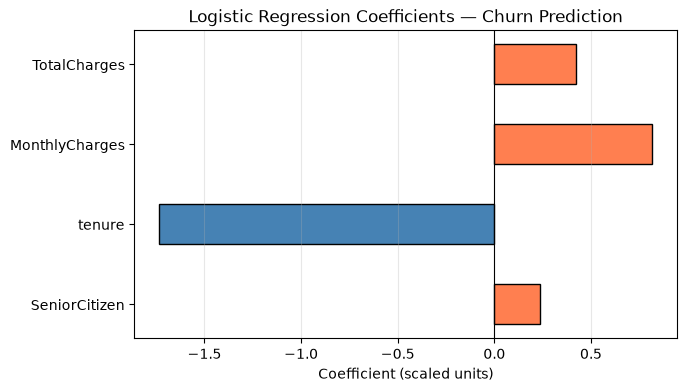

In [33]:
# Visualize coefficients
plt.figure(figsize=(7, 4))
coefs = model.coef_[0]
colors = ['coral' if c > 0 else 'steelblue' for c in coefs]
plt.barh(feature_cols, coefs, color=colors, edgecolor='black', height=0.5)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient (scaled units)')
plt.title('Logistic Regression Coefficients — Churn Prediction')
plt.grid(True, axis='x', alpha=0.3)
plt.show()

> **Note:** Coefficients are in *scaled* units (after `StandardScaler`), so they are directly comparable in magnitude. A larger absolute value means that feature has more influence on the prediction. Raw coefficients from unscaled features cannot be compared this way.

---
## Step 6: Regularization — the C Parameter

A model left to its own devices can fit the training data too closely, chasing patterns that are really just noise in those particular rows. **Regularization** is the standard defense: it adds a penalty on large weights to the quantity the model minimizes, so the solver has to trade off fitting the data against keeping weights small. Smaller weights mean a less extreme model, which usually holds up better on data it has never seen.

sklearn's `LogisticRegression` applies **L2 regularization** by default. It does not minimize log loss alone. What it minimizes is the total log loss plus a penalty on the squared weights:

$$\sum_{i=1}^{n} \text{log loss}_i \;+\; \frac{1}{2C} \sum w^2$$

The first term measures how badly the model fits the training data. The second is the price of using large weights: every weight adds its own square to the bill. Because the solver minimizes the two terms *together*, it will only grow a weight when doing so cuts the loss by more than it adds to the penalty. Weights that do not earn their keep end up small.

The factor $\frac{1}{2C}$ sets how expensive that price is, and it is where `C` earns its reputation for feeling backwards: `C` sits in the denominator, so a *small* `C` makes the penalty term large.

- **Small C** (e.g. 0.01): strong regularization — weights are pushed hard toward zero, which can prevent overfitting but may underfit if pushed too far
- **Large C** (e.g. 100): weak regularization — the model can use large weights and fit the training data more closely

Since the penalty applies to the weights themselves, this is one more reason to scale features first: unscaled, a feature that happens to be measured in small units needs a large weight and gets punished for it.

The loop below fits the same model across a range of `C` values and reports training accuracy, test accuracy, the gap between them, and the total size of the learned weights. A wide train-test gap is the classic signature of overfitting.

In [34]:
C_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

print(f'{'C':>8}  {'Train Acc':>10}  {'Test Acc':>10}  {'Gap':>8}  {'sum |w|':>9}')
print('-' * 53)
for C in C_values:
    m = LogisticRegression(C=C, max_iter=1000, random_state=RANDOM_SEED)
    m.fit(X_train_sc, y_train)
    tr = accuracy_score(y_train, m.predict(X_train_sc))
    te = accuracy_score(y_test,  m.predict(X_test_sc))
    total_weight = np.abs(m.coef_[0]).sum()   # how much weight the model is using in total
    print(f'{C:>8}  {tr:>10.4f}  {te:>10.4f}  {tr-te:>8.4f}  {total_weight:>9.3f}')

       C   Train Acc    Test Acc       Gap    sum |w|
-----------------------------------------------------
   0.001      0.7499      0.7427    0.0072      1.069
    0.01      0.7936      0.7839    0.0097      2.163
     0.1      0.7929      0.7889    0.0040      2.712
     1.0      0.7922      0.7875    0.0047      3.215
    10.0      0.7922      0.7882    0.0040      3.293
   100.0      0.7920      0.7882    0.0038      3.301


> **Note:** Three things to read off this table. First, `sum |w|` falls from 3.30 at `C=100` to 1.07 at `C=0.001` — that column is the penalty visibly doing its job, shrinking the weights as `C` tightens. Second, that shrinking is what produces the `C=0.001` row: squeezed that hard, the model can no longer represent the pattern, and training accuracy drops to 0.750, barely above the 73.4% always-predict-"No" baseline. That is underfitting. Third, from `C=0.01` upward the accuracies barely move and the train-test gap stays under 0.01, so there is no overfitting here to fight: 4 numerical features over 7,000 rows does not give the model enough rope. When you add many encoded categorical features in the Hotel Booking project, regularization will matter much more.

---
## What You Should Be Able to Do Now

- Load a dataset, encode the binary target, and select features for logistic regression
- Apply a **stratified** train/test split and explain why stratification matters for imbalanced targets
- Fit `LogisticRegression` and call both `predict()` and `predict_proba()`
- Compare a model's accuracy against a majority-class baseline
- Interpret the sign and magnitude of `model.coef_` values (in scaled units)
- Explain what regularization does, what the `C` parameter controls, and the direction of its effect